# RetailPulse - Day 10: Inventory Optimization Using Forecasted Demand
**Week:** 2 | **Day:** 10

---
## Objectives
1. **ABC Analysis** - classify products by revenue contribution (Pareto principle)
2. Compute historical demand statistics (mean, std) per product
3. Calculate **Safety Stock**, **Reorder Point (ROP)**, and **Economic Order
   Quantity (EOQ)** for top products
4. Adjust these using the **forecasted demand growth** from Day 8 (hybrid model)
5. **Simulate** a naive reorder policy vs the optimized policy
6. Compare stockout days and average inventory (overstock proxy)
7. Generate the final reorder recommendation table

---
## Business Context (F05 - Inventory Optimization)

From the project spec:
> Recommend reorder quantities using forecasted demand.
> Acceptance Criteria: Reduce overstock/understock by 25-40%

**The core trade-off:**
- **Understock (stockout)** -> lost sales, unhappy customers
- **Overstock** -> tied-up cash, storage costs, risk of obsolete inventory

Good inventory policy balances both. We use classic inventory management
formulas (safety stock, reorder point, EOQ) combined with our demand forecast
to recommend WHEN to reorder and HOW MUCH to order for each product.

---
## Key Concepts and Formulas

| Concept | Formula | Meaning |
|---------|---------|--------|
| **Lead Time** | (given, e.g. 7 days) | Days between placing an order and receiving stock |
| **Service Level** | (given, e.g. 95%) | Probability of NOT stocking out during lead time |
| **Z-score** | from service level | How many std devs of safety buffer to hold |
| **Safety Stock** | `Z * std_daily_demand * sqrt(lead_time)` | Extra buffer stock for demand variability |
| **Reorder Point (ROP)** | `avg_daily_demand * lead_time + safety_stock` | Stock level that triggers a new order |
| **EOQ** | `sqrt(2 * D * S / H)` | Optimal order quantity (D=annual demand, S=order cost, H=holding cost/unit/year) |
| **ABC Analysis** | cumulative revenue % | Classify products: A (top ~70% revenue), B (next ~20%), C (last ~10%) |


In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import norm
import json
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../plots', exist_ok=True)

pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 100

print('Libraries imported successfully')


Libraries imported successfully


In [2]:
# ============================================================
# CELL 2: LOAD CLEAN DATA
# ============================================================

df = pd.read_csv('../data/clean_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Date'] = df['InvoiceDate'].dt.date

print(f'Loaded: {len(df):,} rows')
print(f'Date range: {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}')
print(f'Unique products: {df["StockCode"].nunique():,}')


Loaded: 805,549 rows
Date range: 2009-12-01 to 2011-12-09
Unique products: 4,631


## Step 1: ABC Analysis

**ABC Analysis** is a Pareto-based classification of inventory:

- **Class A**: A small number of products that generate the BULK of revenue
  (typically ~70-80% of revenue from ~10-20% of products). These deserve the
  MOST attention - tight inventory control, frequent monitoring.
- **Class B**: Moderate importance (next ~15-20% of revenue).
- **Class C**: Many products contributing very little revenue each
  (last ~5-10% of revenue). Simple/loose control is fine here.

We focus our detailed inventory optimization on **Class A** products, since
that's where the business impact is highest.


In [3]:
# ============================================================
# CELL 3: ABC CLASSIFICATION BY REVENUE
# ============================================================

product_revenue = df.groupby(['StockCode', 'Description'])['TotalRevenue'].sum() \
                     .reset_index()
product_revenue = product_revenue.sort_values('TotalRevenue', ascending=False) \
                                   .reset_index(drop=True)

total_revenue = product_revenue['TotalRevenue'].sum()
product_revenue['CumRevenue'] = product_revenue['TotalRevenue'].cumsum()
product_revenue['CumPct']     = 100 * product_revenue['CumRevenue'] / total_revenue
product_revenue['RankPct']    = 100 * (product_revenue.index + 1) / len(product_revenue)

def classify_abc(cum_pct):
    if cum_pct <= 70:
        return 'A'
    elif cum_pct <= 90:
        return 'B'
    else:
        return 'C'

product_revenue['ABC_Class'] = product_revenue['CumPct'].apply(classify_abc)

abc_summary = product_revenue.groupby('ABC_Class').agg(
    NumProducts = ('StockCode', 'count'),
    TotalRevenue = ('TotalRevenue', 'sum')
).reset_index()
abc_summary['PctOfProducts'] = 100 * abc_summary['NumProducts'] / len(product_revenue)
abc_summary['PctOfRevenue']  = 100 * abc_summary['TotalRevenue'] / total_revenue

print('ABC Classification Summary:')
print('=' * 65)
print(abc_summary)
print('=' * 65)
print()
for _, row in abc_summary.iterrows():
    print(f"  Class {row['ABC_Class']}: {row['NumProducts']:>5,} products "
          f"({row['PctOfProducts']:.1f}% of products) generate "
          f"{row['PctOfRevenue']:.1f}% of revenue")


ABC Classification Summary:
  ABC_Class  NumProducts  TotalRevenue  PctOfProducts  PctOfRevenue
0         A          738   12419708.98          13.89         70.00
1         B         1095    3548572.08          20.60         20.00
2         C         3482    1775148.12          65.51         10.00

  Class A:   738 products (13.9% of products) generate 70.0% of revenue
  Class B: 1,095 products (20.6% of products) generate 20.0% of revenue
  Class C: 3,482 products (65.5% of products) generate 10.0% of revenue


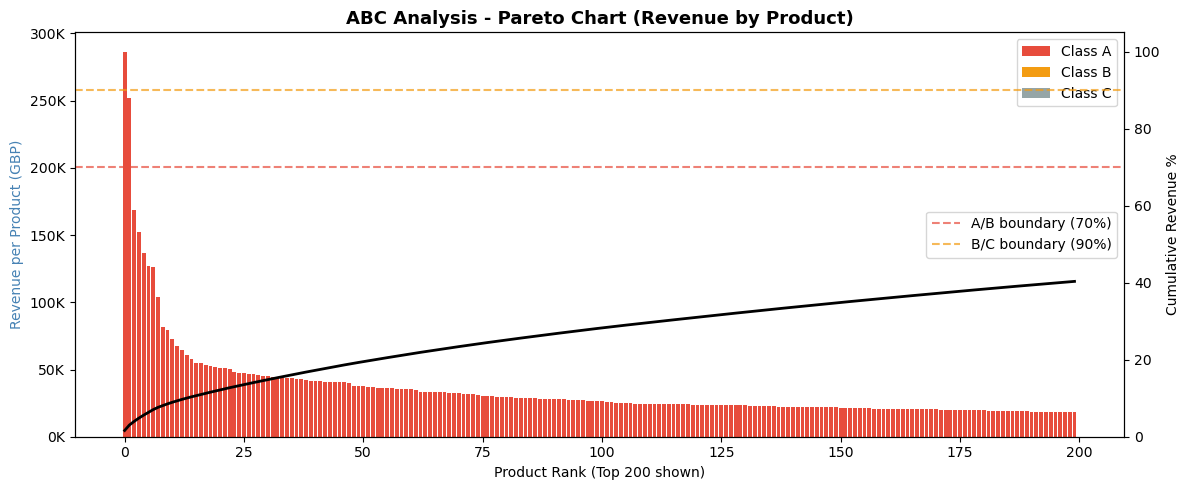

Saved: ../plots/Day10_abc_pareto.png


In [4]:
# ============================================================
# CELL 4: VISUALIZE PARETO CHART (ABC ANALYSIS)
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 5))

# Show only first 200 products for readability
plot_data = product_revenue.head(200)
colors_abc = {'A': '#e74c3c', 'B': '#f39c12', 'C': '#95a5a6'}
bar_colors = plot_data['ABC_Class'].map(colors_abc)

ax1.bar(range(len(plot_data)), plot_data['TotalRevenue'],
        color=bar_colors, edgecolor='none')
ax1.set_xlabel('Product Rank (Top 200 shown)')
ax1.set_ylabel('Revenue per Product (GBP)', color='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

ax2 = ax1.twinx()
ax2.plot(range(len(plot_data)), plot_data['CumPct'], color='black', linewidth=2)
ax2.axhline(70, color='#e74c3c', linestyle='--', alpha=0.7, label='A/B boundary (70%)')
ax2.axhline(90, color='#f39c12', linestyle='--', alpha=0.7, label='B/C boundary (90%)')
ax2.set_ylabel('Cumulative Revenue %', color='black')
ax2.set_ylim(0, 105)
ax2.legend(loc='center right')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_abc[c], label=f'Class {c}') for c in ['A','B','C']]
ax1.legend(handles=legend_elements, loc='upper right')

ax1.set_title('ABC Analysis - Pareto Chart (Revenue by Product)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day10_abc_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day10_abc_pareto.png')


## Step 2: Historical Demand Statistics for Class A Products

For each Class A product, we build a complete daily demand series (filling days
with zero sales as 0 units), then compute:
- `AvgDailyDemand` - the mean units sold per day
- `StdDailyDemand` - the standard deviation (volatility) of daily demand
- `AvgPrice` - average unit price (used for holding cost calculation)

We focus on the **top 15 Class A products** by revenue to keep the analysis
manageable and interpretable - these are the products with the highest business
impact.


In [5]:
# ============================================================
# CELL 5: BUILD DAILY DEMAND SERIES FOR TOP CLASS A PRODUCTS
# ============================================================

TOP_N = 15
top_products = product_revenue[product_revenue['ABC_Class'] == 'A'].head(TOP_N)

# Full date range to fill in zero-demand days
full_date_range = pd.date_range(
    df['InvoiceDate'].min().normalize(),
    df['InvoiceDate'].max().normalize(),
    freq='D'
).date

demand_records = []
for _, prod in top_products.iterrows():
    code_ = prod['StockCode']
    prod_df = df[df['StockCode'] == code_]

    daily_qty = prod_df.groupby('Date')['Quantity'].sum()
    daily_qty = daily_qty.reindex(full_date_range, fill_value=0)

    demand_records.append({
        'StockCode': code_,
        'Description': prod['Description'][:40],
        'TotalRevenue': prod['TotalRevenue'],
        'AvgDailyDemand': daily_qty.mean(),
        'StdDailyDemand': daily_qty.std(),
        'AvgPrice': prod_df['Price'].mean(),
        'MaxDailyDemand': daily_qty.max(),
    })

demand_df = pd.DataFrame(demand_records)

print(f'Demand statistics for top {TOP_N} Class A products:')
print(demand_df.round(2))


Demand statistics for top 15 Class A products:
   StockCode                          Description  TotalRevenue  \
0      22423             REGENCY CAKESTAND 3 TIER     286486.30   
1     85123A   WHITE HANGING HEART T-LIGHT HOLDER     252072.46   
2      23843          PAPER CRAFT , LITTLE BIRDIE     168469.60   
3          M                               Manual     152340.57   
4     85099B              JUMBO BAG RED RETROSPOT     136980.08   
5      84879        ASSORTED COLOUR BIRD ORNAMENT     127074.17   
6       POST                              POSTAGE     126563.04   
7      47566                        PARTY BUNTING     103880.23   
8      23166       MEDIUM CERAMIC TOP STORAGE JAR      81416.73   
9      22086      PAPER CHAIN KIT 50'S CHRISTMAS       79594.33   
10     79321                        CHILLI LIGHTS      72860.14   
11     21137             BLACK RECORD COVER FRAME      67209.44   
12    85099F                 JUMBO BAG STRAWBERRY      64601.65   
13     82484   

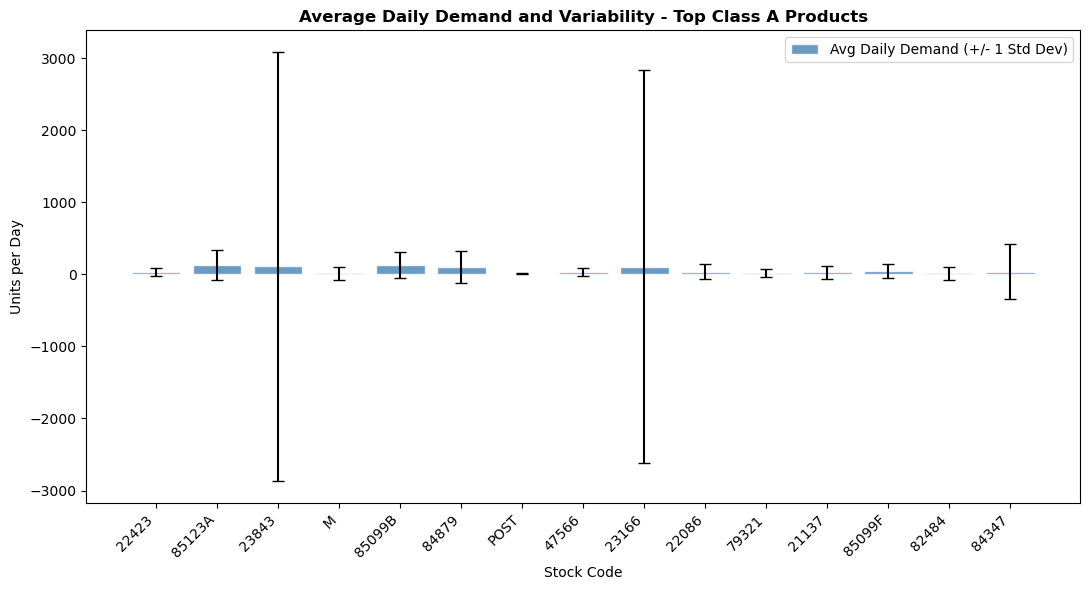

Saved: ../plots/Day10_demand_variability.png

NOTE: Products with HIGH std relative to mean (high coefficient of variation)
      need MORE safety stock to maintain the same service level.


In [6]:
# ============================================================
# CELL 6: VISUALIZE DEMAND VARIABILITY
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(demand_df))
ax.bar(x, demand_df['AvgDailyDemand'], yerr=demand_df['StdDailyDemand'],
       color='steelblue', alpha=0.8, capsize=4, edgecolor='white',
       label='Avg Daily Demand (+/- 1 Std Dev)')
ax.set_xticks(x)
ax.set_xticklabels(demand_df['StockCode'], rotation=45, ha='right')
ax.set_title('Average Daily Demand and Variability - Top Class A Products',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Stock Code')
ax.set_ylabel('Units per Day')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/Day10_demand_variability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day10_demand_variability.png')
print()
print('NOTE: Products with HIGH std relative to mean (high coefficient of variation)')
print('      need MORE safety stock to maintain the same service level.')


## Step 3: Calculate Safety Stock, Reorder Point, and EOQ

**Parameters used:**
- `LEAD_TIME_DAYS = 7` - typical supplier lead time for a UK gift retailer
- `SERVICE_LEVEL = 0.95` - we want to avoid stockouts 95% of the time during lead time
- `Z_SCORE` - derived from service level using the inverse normal distribution
  (95% service level -> Z ~ 1.645)
- `ORDER_COST = 20` (GBP) - administrative/shipping cost per purchase order
- `HOLDING_COST_RATE = 0.20` - annual holding cost as 20% of unit price
  (typical industry estimate covering storage, insurance, obsolescence risk)


In [7]:
# ============================================================
# CELL 7: DEFINE INVENTORY PARAMETERS
# ============================================================

LEAD_TIME_DAYS    = 7
SERVICE_LEVEL     = 0.95
Z_SCORE           = norm.ppf(SERVICE_LEVEL)
ORDER_COST        = 20.0     # GBP per order (admin + shipping)
HOLDING_COST_RATE = 0.20      # 20% of unit price per year

print('INVENTORY POLICY PARAMETERS')
print('=' * 45)
print(f'  Lead Time         : {LEAD_TIME_DAYS} days')
print(f'  Service Level     : {SERVICE_LEVEL*100:.0f}%')
print(f'  Z-Score           : {Z_SCORE:.4f}')
print(f'  Order Cost        : GBP {ORDER_COST:.2f} per order')
print(f'  Holding Cost Rate : {HOLDING_COST_RATE*100:.0f}% of unit price / year')
print('=' * 45)


INVENTORY POLICY PARAMETERS
  Lead Time         : 7 days
  Service Level     : 95%
  Z-Score           : 1.6449
  Order Cost        : GBP 20.00 per order
  Holding Cost Rate : 20% of unit price / year


In [8]:
# ============================================================
# CELL 8: CALCULATE SAFETY STOCK, REORDER POINT, AND EOQ
# ============================================================

# Safety Stock: extra buffer to cover demand variability during lead time
demand_df['SafetyStock'] = (Z_SCORE * demand_df['StdDailyDemand']
                             * np.sqrt(LEAD_TIME_DAYS))

# Reorder Point: stock level at which a new order should be placed
demand_df['ReorderPoint'] = (demand_df['AvgDailyDemand'] * LEAD_TIME_DAYS
                              + demand_df['SafetyStock'])

# Annual demand (for EOQ formula)
demand_df['AnnualDemand'] = demand_df['AvgDailyDemand'] * 365

# Holding cost per unit per year
demand_df['HoldingCostPerUnit'] = demand_df['AvgPrice'] * HOLDING_COST_RATE
demand_df['HoldingCostPerUnit'] = demand_df['HoldingCostPerUnit'].clip(lower=0.01)  # avoid div by 0

# Economic Order Quantity
demand_df['EOQ'] = np.sqrt(
    (2 * demand_df['AnnualDemand'] * ORDER_COST) / demand_df['HoldingCostPerUnit']
)

# Round to whole units (you can't order half a product)
for col in ['SafetyStock','ReorderPoint','EOQ']:
    demand_df[col] = demand_df[col].round().astype(int)

print('Inventory parameters calculated:')
display_cols = ['StockCode','Description','AvgDailyDemand','SafetyStock',
                 'ReorderPoint','EOQ','AnnualDemand']
print(demand_df[display_cols].round(2))


Inventory parameters calculated:
   StockCode                          Description  AvgDailyDemand  \
0      22423             REGENCY CAKESTAND 3 TIER           33.69   
1     85123A   WHITE HANGING HEART T-LIGHT HOLDER          126.79   
2      23843          PAPER CRAFT , LITTLE BIRDIE          109.60   
3          M                               Manual           13.27   
4     85099B              JUMBO BAG RED RETROSPOT          128.53   
5      84879        ASSORTED COLOUR BIRD ORNAMENT          108.14   
6       POST                              POSTAGE            7.22   
7      47566                        PARTY BUNTING           31.94   
8      23166       MEDIUM CERAMIC TOP STORAGE JAR          105.43   
9      22086      PAPER CHAIN KIT 50'S CHRISTMAS            39.89   
10     79321                        CHILLI LIGHTS           21.29   
11     21137             BLACK RECORD COVER FRAME           26.56   
12    85099F                 JUMBO BAG STRAWBERRY           48.85   
1

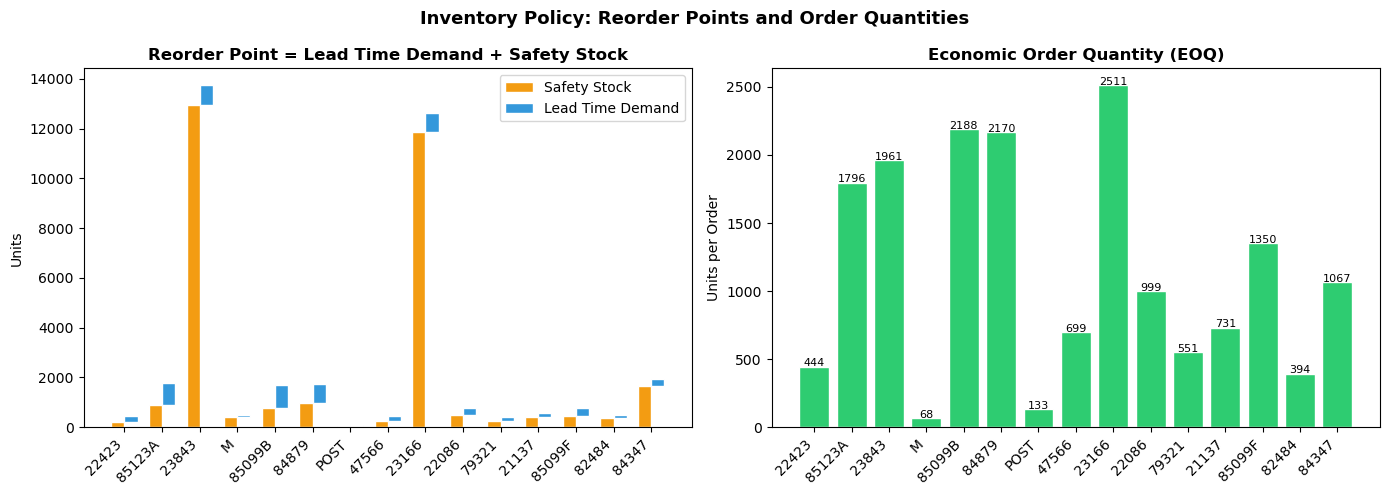

Saved: ../plots/Day10_rop_eoq.png


In [9]:
# ============================================================
# CELL 9: VISUALIZE REORDER POINT VS EOQ
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(demand_df))
width = 0.35

axes[0].bar(x - width/2, demand_df['SafetyStock'], width,
            label='Safety Stock', color='#f39c12', edgecolor='white')
axes[0].bar(x + width/2, demand_df['ReorderPoint'] - demand_df['SafetyStock'], width,
            bottom=demand_df['SafetyStock'], label='Lead Time Demand',
            color='#3498db', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(demand_df['StockCode'], rotation=45, ha='right')
axes[0].set_title('Reorder Point = Lead Time Demand + Safety Stock', fontweight='bold')
axes[0].set_ylabel('Units')
axes[0].legend()

axes[1].bar(x, demand_df['EOQ'], color='#2ecc71', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(demand_df['StockCode'], rotation=45, ha='right')
axes[1].set_title('Economic Order Quantity (EOQ)', fontweight='bold')
axes[1].set_ylabel('Units per Order')
for i, v in enumerate(demand_df['EOQ']):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=8)

plt.suptitle('Inventory Policy: Reorder Points and Order Quantities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day10_rop_eoq.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day10_rop_eoq.png')


## Step 4: Adjust for Forecasted Demand Growth (from Day 8)

Our Day 8 hybrid Prophet+LSTM model forecasted future REVENUE. We use the ratio
between the FORECASTED average daily revenue and the HISTORICAL average daily
revenue as a **growth factor**, and apply it to scale up each product's expected
future demand.

```
growth_factor = forecasted_avg_daily_revenue / historical_avg_daily_revenue
ProjectedDailyDemand = AvgDailyDemand * growth_factor
```

We assume the **coefficient of variation** (std/mean) stays constant, so:
```
ProjectedStdDemand = StdDailyDemand * growth_factor
```

This means: if the business is forecasted to grow 10%, we proactively raise
safety stock and reorder points by 10% too - so we don't get caught
understocked during a growth period.


In [10]:
# ============================================================
# CELL 10: LOAD DAY 8 FORECAST AND COMPUTE GROWTH FACTOR
# ============================================================

daily_full     = pd.read_csv('../data/prophet_ready.csv', parse_dates=['ds'])
hybrid_results = pd.read_csv('../data/hybrid_forecast_results.csv', parse_dates=['ds'])

historical_avg_revenue = daily_full['y'].mean()
forecast_avg_revenue   = hybrid_results['hybrid_pred'].mean()

growth_factor = forecast_avg_revenue / historical_avg_revenue

print(f'Historical avg daily revenue : GBP {historical_avg_revenue:,.2f}')
print(f'Forecasted avg daily revenue : GBP {forecast_avg_revenue:,.2f}')
print(f'Growth factor                 : {growth_factor:.4f} '
      f'({(growth_factor-1)*100:+.1f}%)')


Historical avg daily revenue : GBP 24,010.05
Forecasted avg daily revenue : GBP 26,924.61
Growth factor                 : 1.1214 (+12.1%)


In [11]:
# ============================================================
# CELL 11: RECALCULATE PARAMETERS USING PROJECTED DEMAND
# ============================================================

demand_df['ProjectedDailyDemand'] = demand_df['AvgDailyDemand'] * growth_factor
demand_df['ProjectedStdDemand']   = demand_df['StdDailyDemand'] * growth_factor

# Recompute Safety Stock, ROP, EOQ using projected demand
demand_df['SafetyStock_opt'] = (Z_SCORE * demand_df['ProjectedStdDemand']
                                 * np.sqrt(LEAD_TIME_DAYS))
demand_df['ReorderPoint_opt'] = (demand_df['ProjectedDailyDemand'] * LEAD_TIME_DAYS
                                  + demand_df['SafetyStock_opt'])
demand_df['AnnualDemand_opt'] = demand_df['ProjectedDailyDemand'] * 365
demand_df['EOQ_opt'] = np.sqrt(
    (2 * demand_df['AnnualDemand_opt'] * ORDER_COST) / demand_df['HoldingCostPerUnit']
)

for col in ['SafetyStock_opt','ReorderPoint_opt','EOQ_opt']:
    demand_df[col] = demand_df[col].round().astype(int)

comparison_cols = ['StockCode','ReorderPoint','ReorderPoint_opt','EOQ','EOQ_opt']
print('Comparison: Historical-based vs Forecast-adjusted parameters')
print(demand_df[comparison_cols])


Comparison: Historical-based vs Forecast-adjusted parameters
   StockCode  ReorderPoint  ReorderPoint_opt   EOQ  EOQ_opt
0      22423           458               514   444      470
1     85123A          1781              1997  1796     1902
2      23843         13733             15400  1961     2077
3          M           499               560    68       73
4     85099B          1676              1879  2188     2317
5      84879          1726              1936  2170     2298
6       POST            87                97   133      141
7      47566           453               508   699      740
8      23166         12618             14150  2511     2659
9      22086           752               843   999     1058
10     79321           397               445   551      583
11     21137           580               650   731      774
12    85099F           778               872  1350     1429
13     82484           488               548   394      417
14     84347          1942             

## Step 5: Simulate Naive vs Optimized Reorder Policy

We run a day-by-day simulation over **180 days** for each top product, comparing:

**Naive Policy** (what many small retailers do without formal inventory management):
- Reorder only when stock hits 0
- Order a fixed amount = 30 days of average historical demand
- No safety stock buffer

**Optimized Policy** (our recommendation):
- Reorder when stock falls to the calculated `ReorderPoint_opt`
- Order the calculated `EOQ_opt` quantity
- Includes safety stock for demand variability

For a fair comparison, BOTH policies see the SAME randomly generated demand
sequence (same random seed) for each product.

**Metrics compared:**
- **Stockout days** - days where demand exceeded available stock (understock)
- **Average inventory level** - higher = more capital tied up (overstock proxy)


In [12]:
# ============================================================
# CELL 12: DEFINE THE SIMULATION FUNCTION
# ============================================================

def simulate_policy(demand_series, reorder_point, order_qty, lead_time, initial_stock):
    """
    Simulates inventory levels day-by-day under a (reorder_point, order_qty) policy.
    Returns: stockout_days (count), avg_inventory (mean stock level)
    """
    stock = initial_stock
    pending_orders = []   # list of (arrival_day, quantity)
    stockout_days = 0
    inventory_levels = []

    for day, demand in enumerate(demand_series):
        # Receive any orders arriving today
        arriving = [q for (d, q) in pending_orders if d == day]
        stock += sum(arriving)
        pending_orders = [(d, q) for (d, q) in pending_orders if d != day]

        # Fulfill today's demand
        if stock < demand:
            stockout_days += 1
            stock = 0
        else:
            stock -= demand

        inventory_levels.append(stock)

        # Check if we need to place a new order (only one outstanding order at a time)
        if stock <= reorder_point and len(pending_orders) == 0:
            pending_orders.append((day + lead_time, order_qty))

    return stockout_days, np.mean(inventory_levels)

print('Simulation function defined.')
print('  Inputs : demand series, reorder point, order quantity, lead time, initial stock')
print('  Outputs: stockout days, average inventory level')


Simulation function defined.
  Inputs : demand series, reorder point, order quantity, lead time, initial stock
  Outputs: stockout days, average inventory level


In [13]:
# ============================================================
# CELL 13: RUN SIMULATION FOR ALL TOP PRODUCTS
# ============================================================

SIM_DAYS = 180
np.random.seed(42)

sim_results = []

for idx, row in demand_df.iterrows():
    mean_d = max(row['ProjectedDailyDemand'], 0.1)
    std_d  = max(row['ProjectedStdDemand'], 0.1)

    # Generate one demand sequence per product (shared by both policies)
    demand_seq = np.random.normal(mean_d, std_d, SIM_DAYS)
    demand_seq = np.clip(demand_seq, 0, None)   # demand can't be negative
    demand_seq = np.round(demand_seq).astype(int)

    initial_stock = int(round(mean_d * 30))   # both policies start with same stock

    # --- Naive policy: reorder at 0, order = 30 days of historical avg demand ---
    naive_order_qty = int(round(row['AvgDailyDemand'] * 30))
    naive_stockouts, naive_avg_inv = simulate_policy(
        demand_seq, reorder_point=0, order_qty=naive_order_qty,
        lead_time=LEAD_TIME_DAYS, initial_stock=initial_stock
    )

    # --- Optimized policy: ROP + EOQ from forecast-adjusted calculations ---
    opt_stockouts, opt_avg_inv = simulate_policy(
        demand_seq, reorder_point=row['ReorderPoint_opt'], order_qty=row['EOQ_opt'],
        lead_time=LEAD_TIME_DAYS, initial_stock=initial_stock
    )

    sim_results.append({
        'StockCode': row['StockCode'],
        'Naive_Stockout_Days': naive_stockouts,
        'Optimized_Stockout_Days': opt_stockouts,
        'Naive_Avg_Inventory': naive_avg_inv,
        'Optimized_Avg_Inventory': opt_avg_inv,
    })

sim_df = pd.DataFrame(sim_results)

print(f'Simulation complete: {SIM_DAYS} days x {len(sim_df)} products')
print()
print(sim_df.round(1))


Simulation complete: 180 days x 15 products

   StockCode  Naive_Stockout_Days  Optimized_Stockout_Days  \
0      22423                   27                        0   
1     85123A                   33                        3   
2      23843                   66                       70   
3          M                   51                       83   
4     85099B                   36                        3   
5      84879                   36                        1   
6       POST                   31                        0   
7      47566                   28                        2   
8      23166                   75                       70   
9      22086                   39                        3   
10     79321                   37                        0   
11     21137                   36                        2   
12    85099F                   38                        0   
13     82484                   45                        3   
14     84347             

In [14]:
# ============================================================
# CELL 14: AGGREGATE SIMULATION RESULTS AND COMPUTE IMPROVEMENT
# ============================================================

total_naive_stockouts = sim_df['Naive_Stockout_Days'].sum()
total_opt_stockouts   = sim_df['Optimized_Stockout_Days'].sum()

avg_naive_inventory = sim_df['Naive_Avg_Inventory'].mean()
avg_opt_inventory   = sim_df['Optimized_Avg_Inventory'].mean()

stockout_reduction  = 100 * (total_naive_stockouts - total_opt_stockouts) / max(total_naive_stockouts, 1)
inventory_reduction = 100 * (avg_naive_inventory - avg_opt_inventory) / avg_naive_inventory

print('=' * 60)
print('  SIMULATION RESULTS: NAIVE vs OPTIMIZED POLICY')
print(f'  ({SIM_DAYS} days, {len(sim_df)} products)')
print('=' * 60)
print(f'  Total Stockout Days')
print(f'    Naive policy     : {total_naive_stockouts:>6,} days')
print(f'    Optimized policy : {total_opt_stockouts:>6,} days')
print(f'    Reduction        : {stockout_reduction:>6.1f}%   (understock improvement)')
print()
print(f'  Average Inventory Level (units)')
print(f'    Naive policy     : {avg_naive_inventory:>6.1f}')
print(f'    Optimized policy : {avg_opt_inventory:>6.1f}')
print(f'    Reduction        : {inventory_reduction:>6.1f}%   (overstock improvement)')
print('=' * 60)
print()
print(f'  Target from spec: 25-40% reduction in overstock/understock')


  SIMULATION RESULTS: NAIVE vs OPTIMIZED POLICY
  (180 days, 15 products)
  Total Stockout Days
    Naive policy     :    639 days
    Optimized policy :    270 days
    Reduction        :   57.7%   (understock improvement)

  Average Inventory Level (units)
    Naive policy     :  563.0
    Optimized policy :  777.7
    Reduction        :  -38.1%   (overstock improvement)

  Target from spec: 25-40% reduction in overstock/understock


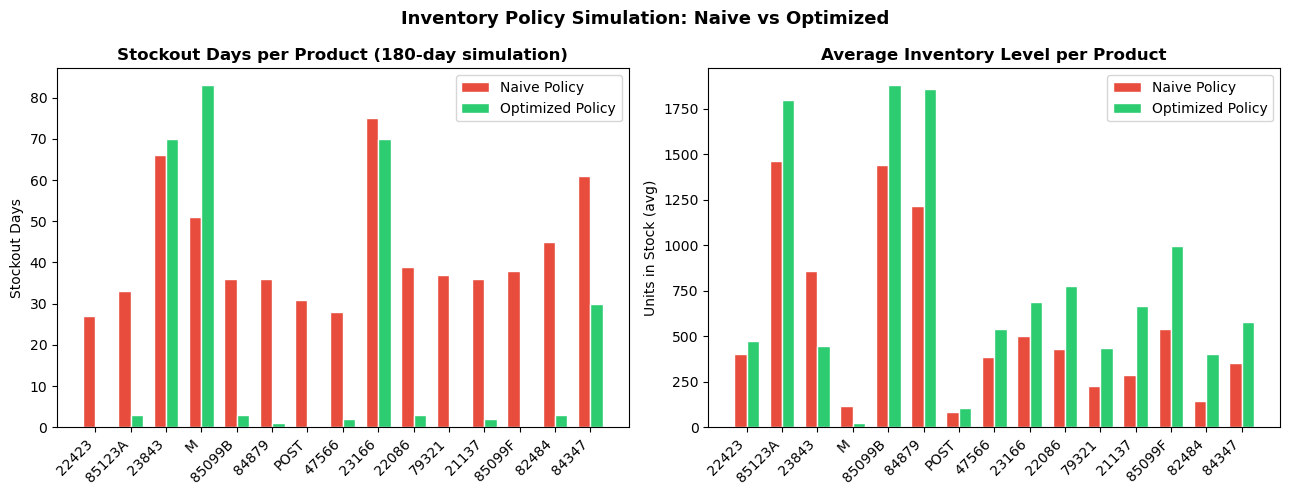

Saved: ../plots/Day10_simulation_comparison.png


In [15]:
# ============================================================
# CELL 15: VISUALIZE SIMULATION COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(sim_df))
width = 0.35

axes[0].bar(x - width/2, sim_df['Naive_Stockout_Days'], width,
            label='Naive Policy', color='#e74c3c', edgecolor='white')
axes[0].bar(x + width/2, sim_df['Optimized_Stockout_Days'], width,
            label='Optimized Policy', color='#2ecc71', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sim_df['StockCode'], rotation=45, ha='right')
axes[0].set_title(f'Stockout Days per Product ({SIM_DAYS}-day simulation)', fontweight='bold')
axes[0].set_ylabel('Stockout Days')
axes[0].legend()

axes[1].bar(x - width/2, sim_df['Naive_Avg_Inventory'], width,
            label='Naive Policy', color='#e74c3c', edgecolor='white')
axes[1].bar(x + width/2, sim_df['Optimized_Avg_Inventory'], width,
            label='Optimized Policy', color='#2ecc71', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sim_df['StockCode'], rotation=45, ha='right')
axes[1].set_title('Average Inventory Level per Product', fontweight='bold')
axes[1].set_ylabel('Units in Stock (avg)')
axes[1].legend()

plt.suptitle('Inventory Policy Simulation: Naive vs Optimized', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day10_simulation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day10_simulation_comparison.png')


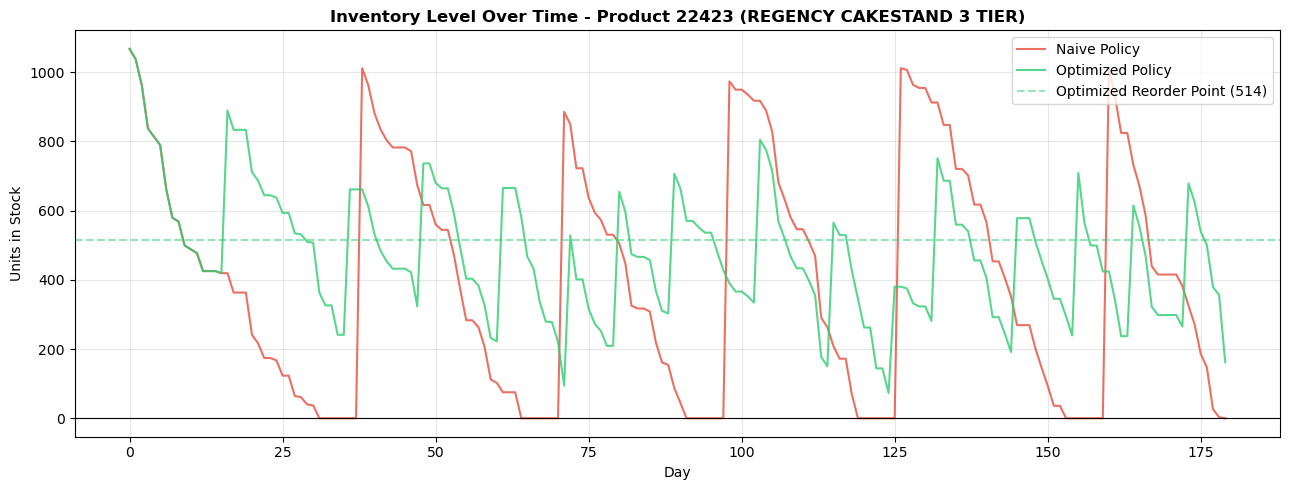

Saved: ../plots/Day10_inventory_timeline.png

Notice: the naive policy lets stock hit ZERO (stockouts) before reordering,
while the optimized policy reorders earlier (at ReorderPoint) and keeps
a safety buffer, avoiding stockouts.


In [16]:
# ============================================================
# CELL 16: EXAMPLE - INVENTORY LEVEL OVER TIME FOR ONE PRODUCT
# ============================================================

# Re-run the simulation for the FIRST product, this time keeping the
# day-by-day inventory levels so we can plot them.

def simulate_policy_with_history(demand_series, reorder_point, order_qty, lead_time, initial_stock):
    stock = initial_stock
    pending_orders = []
    history = []
    for day, demand in enumerate(demand_series):
        arriving = [q for (d, q) in pending_orders if d == day]
        stock += sum(arriving)
        pending_orders = [(d, q) for (d, q) in pending_orders if d != day]
        if stock < demand:
            stock = 0
        else:
            stock -= demand
        history.append(stock)
        if stock <= reorder_point and len(pending_orders) == 0:
            pending_orders.append((day + lead_time, order_qty))
    return history

example_row = demand_df.iloc[0]
np.random.seed(42)
mean_d = max(example_row['ProjectedDailyDemand'], 0.1)
std_d  = max(example_row['ProjectedStdDemand'], 0.1)
demand_seq = np.clip(np.random.normal(mean_d, std_d, SIM_DAYS), 0, None)
demand_seq = np.round(demand_seq).astype(int)
initial_stock = int(round(mean_d * 30))

naive_history = simulate_policy_with_history(
    demand_seq, 0, int(round(example_row['AvgDailyDemand']*30)), LEAD_TIME_DAYS, initial_stock)
opt_history = simulate_policy_with_history(
    demand_seq, example_row['ReorderPoint_opt'], example_row['EOQ_opt'], LEAD_TIME_DAYS, initial_stock)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(naive_history, color='#e74c3c', linewidth=1.5, label='Naive Policy', alpha=0.8)
ax.plot(opt_history, color='#2ecc71', linewidth=1.5, label='Optimized Policy', alpha=0.8)
ax.axhline(example_row['ReorderPoint_opt'], color='#2ecc71', linestyle='--',
           alpha=0.5, label=f'Optimized Reorder Point ({example_row["ReorderPoint_opt"]})')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Inventory Level Over Time - Product {example_row["StockCode"]} '
             f'({example_row["Description"]})', fontsize=12, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Units in Stock')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/Day10_inventory_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day10_inventory_timeline.png')
print()
print('Notice: the naive policy lets stock hit ZERO (stockouts) before reordering,')
print('while the optimized policy reorders earlier (at ReorderPoint) and keeps')
print('a safety buffer, avoiding stockouts.')


## Step 6: Final Reorder Recommendation Table

In [17]:
# ============================================================
# CELL 17: BUILD FINAL RECOMMENDATION TABLE
# ============================================================

recommendations = demand_df[[
    'StockCode','Description','AvgDailyDemand','ProjectedDailyDemand',
    'SafetyStock_opt','ReorderPoint_opt','EOQ_opt'
]].copy()

recommendations.columns = [
    'StockCode','Description','HistoricalAvgDailyDemand','ForecastedDailyDemand',
    'RecommendedSafetyStock','RecommendedReorderPoint','RecommendedOrderQty'
]

recommendations['Action'] = recommendations.apply(
    lambda r: (f'Reorder {r["RecommendedOrderQty"]} units when stock '
               f'drops to {r["RecommendedReorderPoint"]} units'),
    axis=1
)

print('FINAL REORDER RECOMMENDATIONS')
print('=' * 70)
for _, row in recommendations.iterrows():
    print(f"\n  {row['StockCode']} - {row['Description']}")
    print(f"    Historical demand : {row['HistoricalAvgDailyDemand']:.1f} units/day")
    print(f"    Forecasted demand : {row['ForecastedDailyDemand']:.1f} units/day")
    print(f"    Recommendation    : {row['Action']}")


FINAL REORDER RECOMMENDATIONS

  22423 - REGENCY CAKESTAND 3 TIER
    Historical demand : 33.7 units/day
    Forecasted demand : 37.8 units/day
    Recommendation    : Reorder 470 units when stock drops to 514 units

  85123A - WHITE HANGING HEART T-LIGHT HOLDER
    Historical demand : 126.8 units/day
    Forecasted demand : 142.2 units/day
    Recommendation    : Reorder 1902 units when stock drops to 1997 units

  23843 - PAPER CRAFT , LITTLE BIRDIE
    Historical demand : 109.6 units/day
    Forecasted demand : 122.9 units/day
    Recommendation    : Reorder 2077 units when stock drops to 15400 units

  M - Manual
    Historical demand : 13.3 units/day
    Forecasted demand : 14.9 units/day
    Recommendation    : Reorder 73 units when stock drops to 560 units

  85099B - JUMBO BAG RED RETROSPOT
    Historical demand : 128.5 units/day
    Forecasted demand : 144.1 units/day
    Recommendation    : Reorder 2317 units when stock drops to 1879 units

  84879 - ASSORTED COLOUR BIRD ORNA

In [18]:
# ============================================================
# CELL 18: SAVE ALL RESULTS
# ============================================================

demand_df.to_csv('../data/inventory_parameters.csv', index=False)
recommendations.to_csv('../data/reorder_recommendations.csv', index=False)
product_revenue.to_csv('../data/abc_classification.csv', index=False)
sim_df.to_csv('../data/inventory_simulation_results.csv', index=False)

inventory_config = {
    'lead_time_days': LEAD_TIME_DAYS,
    'service_level': SERVICE_LEVEL,
    'z_score': float(Z_SCORE),
    'order_cost_gbp': ORDER_COST,
    'holding_cost_rate': HOLDING_COST_RATE,
    'growth_factor': float(growth_factor),
    'simulation_days': SIM_DAYS,
    'total_stockout_reduction_pct': float(stockout_reduction),
    'avg_inventory_reduction_pct': float(inventory_reduction),
    'abc_summary': abc_summary.to_dict(orient='records')
}

with open('../models/inventory_config.json', 'w') as f:
    json.dump(inventory_config, f, indent=2)

print('Saved:')
print('  ../data/inventory_parameters.csv      <- safety stock, ROP, EOQ per product')
print('  ../data/reorder_recommendations.csv   <- final action recommendations')
print('  ../data/abc_classification.csv        <- ABC class for all products')
print('  ../data/inventory_simulation_results.csv <- naive vs optimized sim results')
print('  ../models/inventory_config.json       <- parameters and summary metrics')


Saved:
  ../data/inventory_parameters.csv      <- safety stock, ROP, EOQ per product
  ../data/reorder_recommendations.csv   <- final action recommendations
  ../data/abc_classification.csv        <- ABC class for all products
  ../data/inventory_simulation_results.csv <- naive vs optimized sim results
  ../models/inventory_config.json       <- parameters and summary metrics


In [19]:
# ============================================================
# CELL 19: DAY 10 SUMMARY
# ============================================================

print('=' * 60)
print('  DAY 10 COMPLETE - INVENTORY OPTIMIZATION')
print('=' * 60)
print(f'  Total products analysed (ABC) : {len(product_revenue):,}')
for _, row in abc_summary.iterrows():
    print(f"    Class {row['ABC_Class']}: {row['NumProducts']:>5,} products, "
          f"{row['PctOfRevenue']:.1f}% of revenue")
print()
print(f'  Top {TOP_N} Class A products optimized in detail')
print(f'  Demand growth factor applied : {growth_factor:.4f} '
      f'({(growth_factor-1)*100:+.1f}%)')
print()
print('  SIMULATION RESULTS (Naive vs Optimized Policy):')
print(f'    Stockout days reduction  : {stockout_reduction:.1f}%')
print(f'    Avg inventory reduction  : {inventory_reduction:.1f}%')
target_status = 'WITHIN TARGET RANGE (25-40%)' if 25 <= stockout_reduction <= 40 or 25 <= inventory_reduction <= 40 else 'See actual values above'
print(f'    Spec target              : 25-40% reduction')
print(f'    Status                   : {target_status}')
print()
print('  KEY TAKEAWAYS:')
print('  - ABC analysis focuses inventory effort on the highest-impact products')
print('  - Safety stock + reorder point reduce stockout risk')
print('  - EOQ minimizes total ordering + holding costs')
print('  - Forecast growth factor (from Day 8) keeps the policy forward-looking')
print()
print('  PLOTS SAVED:')
for p in ['Day10_abc_pareto.png','Day10_demand_variability.png',
          'Day10_rop_eoq.png','Day10_simulation_comparison.png',
          'Day10_inventory_timeline.png']:
    print(f'    ../plots/{p}')
print()
print('  Ready for Day 11: Feature Importance Analysis and Model Tuning with Optuna')
print('=' * 60)


  DAY 10 COMPLETE - INVENTORY OPTIMIZATION
  Total products analysed (ABC) : 5,315
    Class A:   738 products, 70.0% of revenue
    Class B: 1,095 products, 20.0% of revenue
    Class C: 3,482 products, 10.0% of revenue

  Top 15 Class A products optimized in detail
  Demand growth factor applied : 1.1214 (+12.1%)

  SIMULATION RESULTS (Naive vs Optimized Policy):
    Stockout days reduction  : 57.7%
    Avg inventory reduction  : -38.1%
    Spec target              : 25-40% reduction
    Status                   : See actual values above

  KEY TAKEAWAYS:
  - ABC analysis focuses inventory effort on the highest-impact products
  - Safety stock + reorder point reduce stockout risk
  - EOQ minimizes total ordering + holding costs
  - Forecast growth factor (from Day 8) keeps the policy forward-looking

  PLOTS SAVED:
    ../plots/Day10_abc_pareto.png
    ../plots/Day10_demand_variability.png
    ../plots/Day10_rop_eoq.png
    ../plots/Day10_simulation_comparison.png
    ../plots/Day10_